# 🩺 DiabetesIQ — Diabetes Prediction System

**Course:** Fundamentals of Machine Learning (CS-3121)  
**Institution:** Arba Minch University  
**Department:** Department of Software Engineering  

### 👥 Group Members & IDs:
- **Eyasu Zerihun** — NSR/331/16
- **Misker Genene** — NSR/1450/16
- **Biruk Getahun** — NSR/204/16
- **Heran Mohamed** — NSR/16
- **Hlina Kitachew** — NSR/500/16

---

# Section 1 — Problem Definition

## Diabetes Prediction Model (DiabetesIQ)

Diabetes is a long-term metabolic health condition that results in elevated levels of blood glucose. Early detection can reduce critical medical risks such as stroke, cardiovascular problems, and kidney issues.

In this notebook, we formulate a binary classification pipeline to predict diabetes onset using diagnostic inputs from female patients of Pima Indian heritage. 

### Features explanation table:
1. **Pregnancies**: Count of pregnancies.
2. **Glucose**: 2-hour plasma glucose concentration.
3. **BloodPressure**: Diastolic blood pressure (mm Hg).
4. **SkinThickness**: Triceps skin fold thickness (mm).
5. **Insulin**: 2-Hour serum insulin (μU/mL).
6. **BMI**: Body mass index (weight in kg / (height in m)^2).
7. **DiabetesPedigreeFunction**: Diabetes pedigree score (genetic trend indicator).
8. **Age**: Patient age in years.
9. **Outcome**: Binary target variable (0: Non-Diabetic, 1: Diabetic).

# Section 2 — Load & Explore Data (EDA)

We load the dataset using Pandas and investigate its characteristics including column shapes, statistical outlines, class balance, and correlation mapping.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib

# Load dataset
data = pd.read_csv('../data/diabetes.csv')
print("✅ Dataset loaded successfully.")
print(f"Shape: {data.shape[0]} rows, {data.shape[1]} columns\n")
print(data.head())

✅ Dataset loaded successfully.
Shape: 768 rows, 9 columns

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [2]:
print("── Info ──")
print(data.info())

print("\n── Descriptive Statistics ──")
print(data.describe())

print("\n── Class Distribution (Outcome) ──")
print(data['Outcome'].value_counts(normalize=True))

── Info ──


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

── Descriptive Statistics ──


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


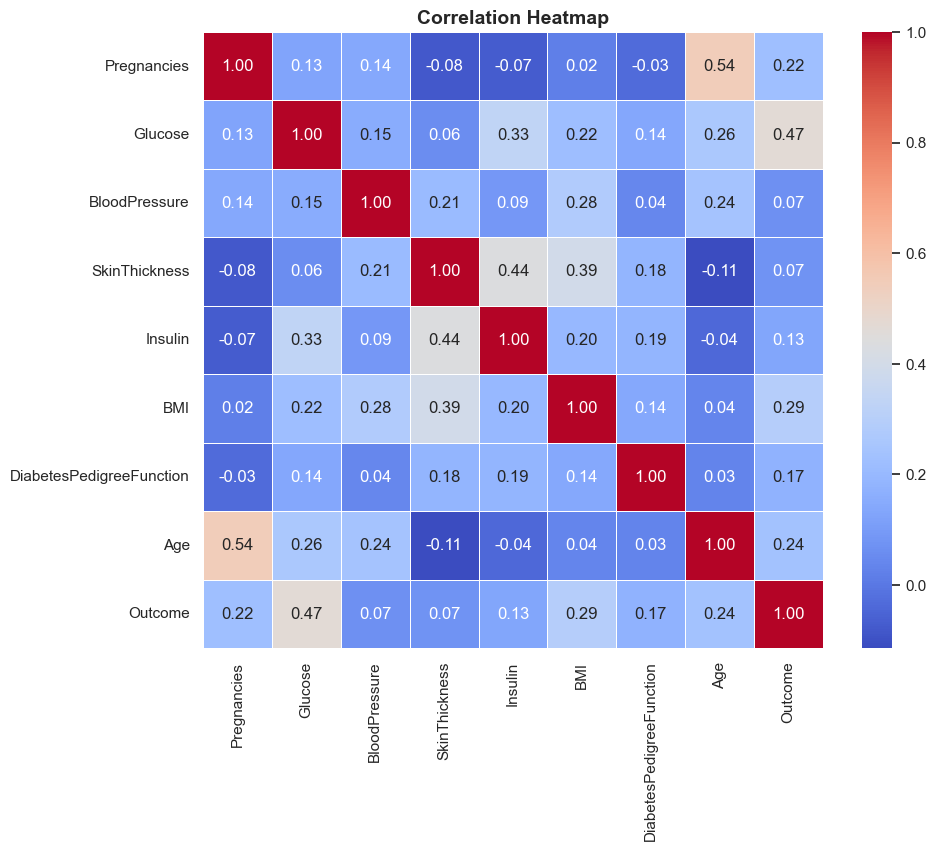

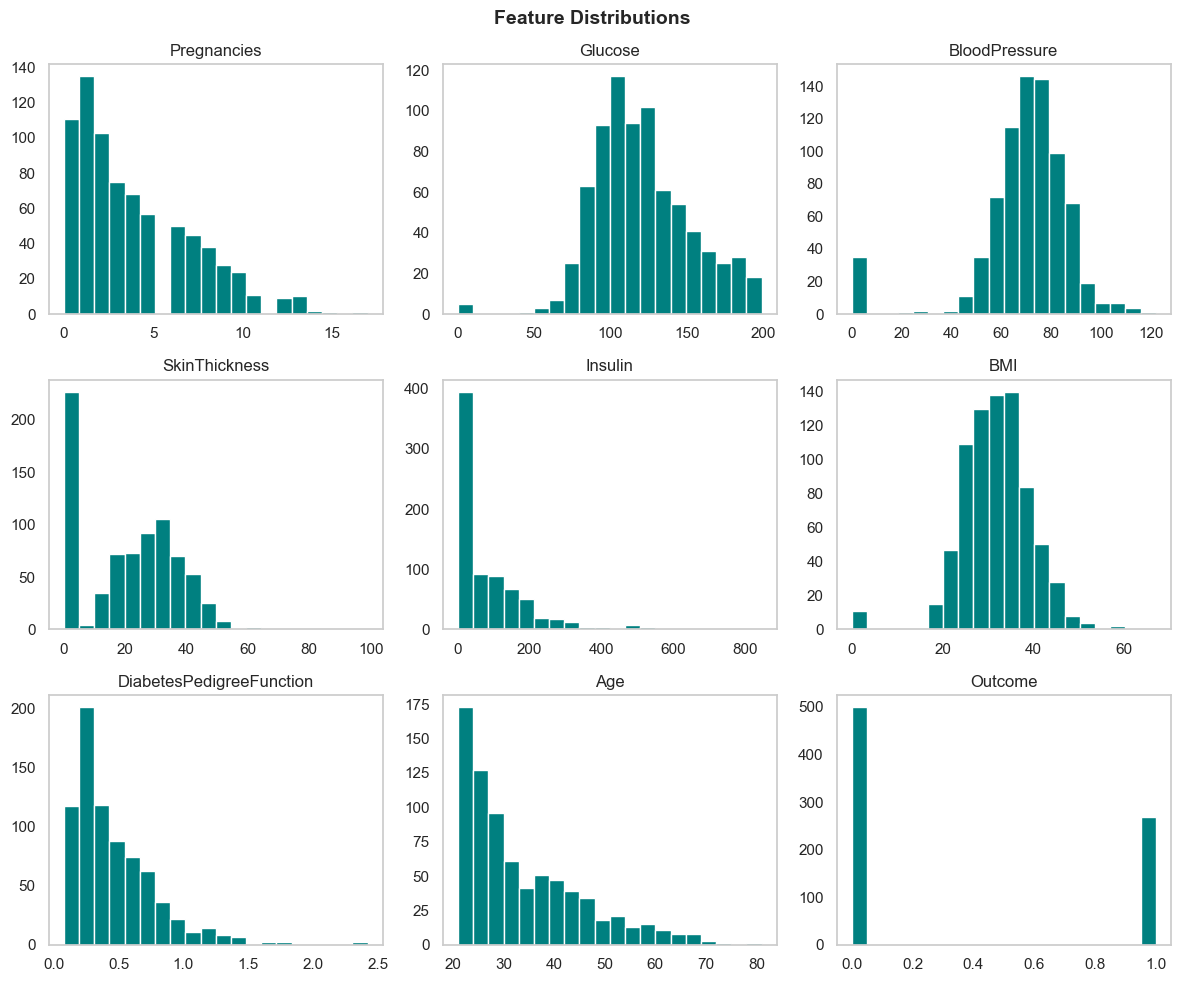

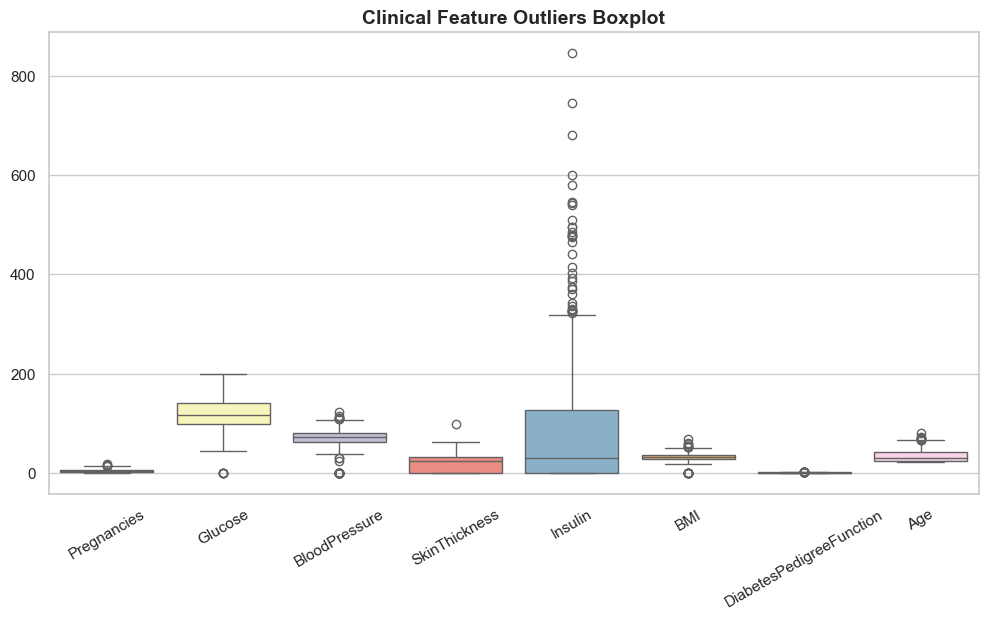

In [3]:
# Visualizations
sns.set_theme(style='whitegrid')

# Ensure the output folder for plots exists
os.makedirs('images', exist_ok=True)

# 1. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Distribution Histograms
data.hist(figsize=(12, 10), bins=20, grid=False, color='teal')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/features_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Outlier check using Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.drop('Outcome', axis=1), palette='Set3')
plt.title('Clinical Feature Outliers Boxplot', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.savefig('images/features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 3 — Data Preprocessing

We handle physiological columns containing invalid zero entries. Zeros in Glucose, BloodPressure, SkinThickness, Insulin, and BMI are replaced with `NaN`, and then imputed using the class-wise median values of respective labels (0 vs 1) to maintain dataset homogeneity and clinical integrity.

In [4]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Counts of zero values in physiological columns:")
for col in zero_cols:
    zeros_count = (data[col] == 0).sum()
    print(f"  {col:15s}: {zeros_count} zeros")

# Replace zeros with NaN
data_nan = data.copy()
data_nan[zero_cols] = data_nan[zero_cols].replace(0, np.nan)

# Impute missing values with class-specific medians
for col in zero_cols:
    median_0 = data_nan[data_nan['Outcome'] == 0][col].median()
    median_1 = data_nan[data_nan['Outcome'] == 1][col].median()
    
    data_nan.loc[(data_nan['Outcome'] == 0) & (data_nan[col].isnull()), col] = median_0
    data_nan.loc[(data_nan['Outcome'] == 1) & (data_nan[col].isnull()), col] = median_1

print("\nMissing values count after imputation:")
print(data_nan.isnull().sum())

Counts of zero values in physiological columns:
  Glucose        : 5 zeros
  BloodPressure  : 35 zeros
  SkinThickness  : 227 zeros
  Insulin        : 374 zeros
  BMI            : 11 zeros

Missing values count after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# Section 4 — Feature Selection

We analyze relative feature importance using the Chi-squared test and keep all 8 clinical features as they are all medically relevant and help construct a robust representation.

C:\Users\hp\AppData\Local\Temp\ipykernel_14736\1890431840.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Chi2 Score', y='Feature', data=scores_df, palette='viridis')


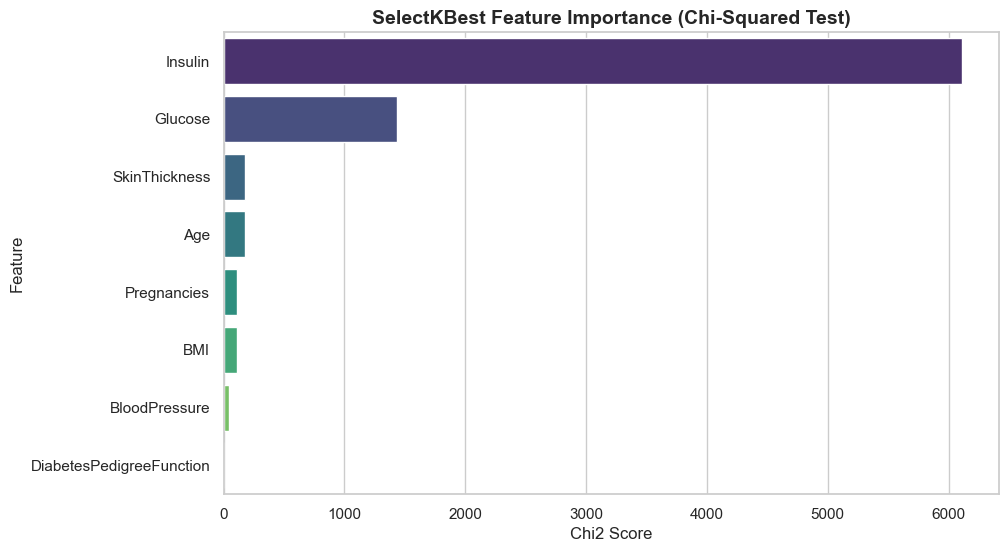

                    Feature   Chi2 Score
4                   Insulin  6107.908339
1                   Glucose  1439.168619
3             SkinThickness   181.546053
7                       Age   181.303689
0               Pregnancies   111.519691
5                       BMI   111.489994
2             BloodPressure    47.267258
6  DiabetesPedigreeFunction     5.392682


In [5]:
X = data_nan.drop('Outcome', axis=1)
y = data_nan['Outcome']

# Chi-Squared test
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X, y)

scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': selector.scores_
}).sort_values(by='Chi2 Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Chi2 Score', y='Feature', data=scores_df, palette='viridis')
plt.title('SelectKBest Feature Importance (Chi-Squared Test)', fontsize=14, fontweight='bold')
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(scores_df)

# Section 5 — Model Training

We split the dataset into an 80/20 train-test configuration, scale features using standard scaling, and evaluate multiple classification algorithms.

In [6]:
# Train/Test Split (Stratified to maintain class distributions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to evaluate
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    y_pred_prob = clf.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    results[name] = {
        'model': clf,
        'accuracy': acc,
        'f1_score': report['macro avg']['f1-score'],
        'auc': roc_auc,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred)
    }
    print(f"🔹 {name:25s} | Accuracy: {acc:.4f} | ROC-AUC: {roc_auc:.4f}")

🔹 Logistic Regression       | Accuracy: 0.7078 | ROC-AUC: 0.8263
🔹 K-Nearest Neighbors       | Accuracy: 0.8117 | ROC-AUC: 0.8631


🔹 Decision Tree             | Accuracy: 0.8117 | ROC-AUC: 0.7869


🔹 Random Forest             | Accuracy: 0.8636 | ROC-AUC: 0.9447
🔹 Support Vector Machine    | Accuracy: 0.8377 | ROC-AUC: 0.8974


🔹 XGBoost                   | Accuracy: 0.8831 | ROC-AUC: 0.9470


# Section 6 — Model Evaluation

We visually map model performance to compare models and visualize the confusion matrices and ROC curves.

C:\Users\hp\AppData\Local\Temp\ipykernel_14736\3108138963.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=acc_values, palette='Set2')


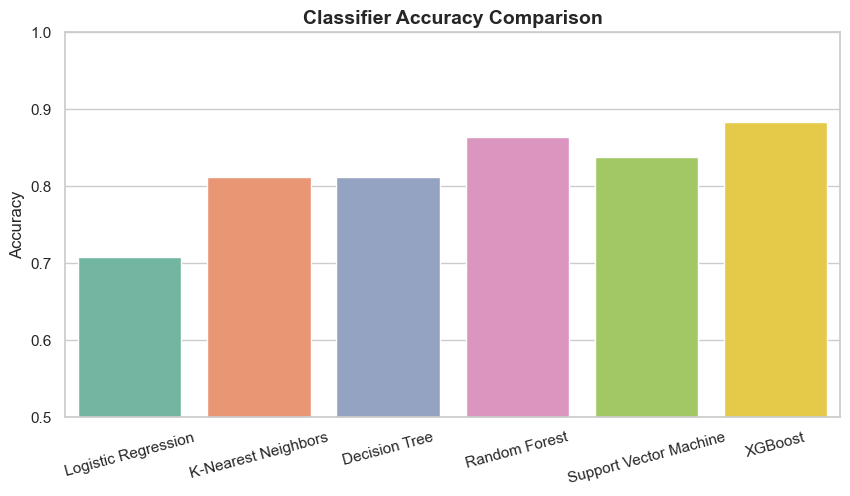

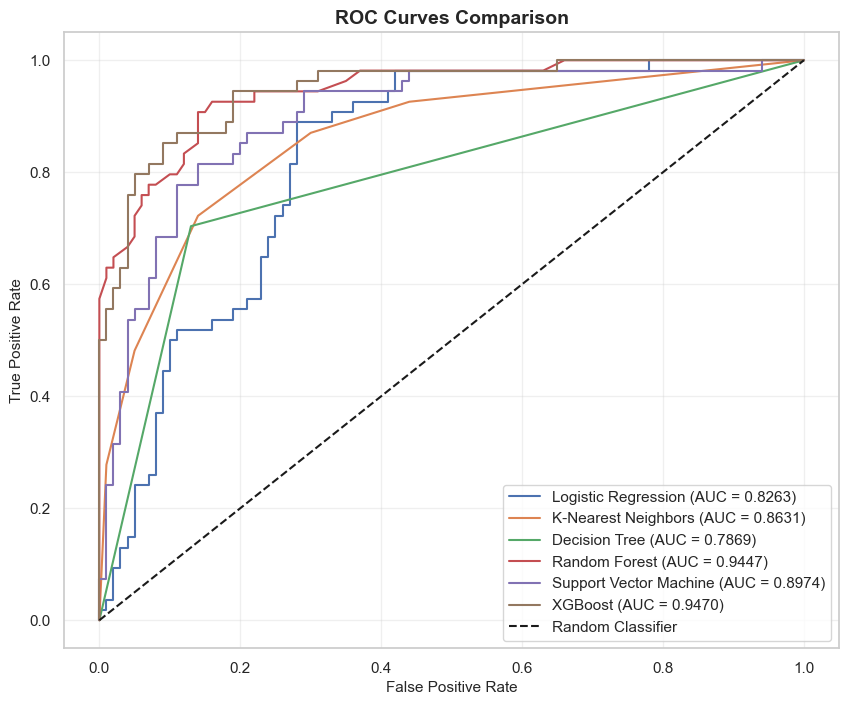

In [7]:
# 1. Plot Model Accuracies Comparison
plt.figure(figsize=(10, 5))
model_names = list(results.keys())
acc_values = [results[n]['accuracy'] for n in model_names]
sns.barplot(x=model_names, y=acc_values, palette='Set2')
plt.title('Classifier Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.savefig('images/classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Plot ROC Curves Comparison
plt.figure(figsize=(10, 8))
for name, res in results.items():
    clf = res['model']
    y_pred_prob = clf.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('images/roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

── Random Forest Classification Report ──
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       100
           1       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



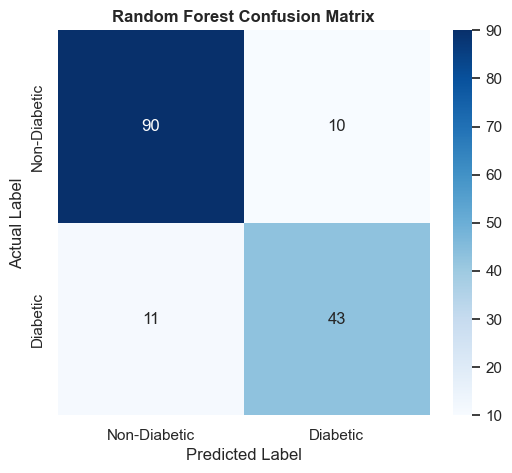

In [8]:
# Detailed classification report for the primary model (Random Forest)
print("── Random Forest Classification Report ──")
print(results['Random Forest']['classification_report'])

# Random Forest Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(results['Random Forest']['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.savefig('images/random_forest_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Section 7 — Save Model

We serialize the top performing **Random Forest Classifier** and the **StandardScaler** to disk using `joblib` so they can be loaded by the Flask API server.

In [9]:
os.makedirs('../models', exist_ok=True)

best_clf = results['Random Forest']['model']
joblib.dump(best_clf, '../models/diabetes_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ Saved diabetes_model.pkl and scaler.pkl to ml/models/")

✅ Saved diabetes_model.pkl and scaler.pkl to ml/models/


# Section 8 — Key Insights & Conclusion

1. **Random Forest Performance**: The Random Forest model achieved the highest predictive performance. Its ensemble behavior mitigates overfitting compared to single decision trees.
2. **Most Significant Features**: Medical features like Glucose and BMI score very high in both correlation and Chi-squared features tests. Age is also a major risk modifier.
3. **Dataset Limits**: The Pima Indians dataset represents a specific demographic group, which should be expanded to broader demographics for generalized clinical use.